In [ ]:
import os, sys, gzip, bz2, lzma, time, math, textwrap, warnings
import xml.etree.ElementTree as ET
from dataclasses import dataclass, field
from enum import Enum
import numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import scipy
from scipy import signal, stats, optimize

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.random.seed(20260815)
IN_COLAB = "google.colab" in sys.modules
OUT = "/content/labplot_out" if IN_COLAB else os.path.join(os.getcwd(), "labplot_out")
os.makedirs(OUT, exist_ok=True)
try:    from pylabplot import *; HAVE_SDK = True
except Exception: HAVE_SDK = False
banner = lambda t: print("\n" + "=" * 76 + f"\n  {t}\n" + "=" * 76)

banner("environment")
print(f"  numpy {np.__version__} | scipy {scipy.__version__} | mpl {matplotlib.__version__} | "
      f"colab={IN_COLAB} | pylabplot={'yes' if HAVE_SDK else 'no -> emulation'}\n  -> {OUT}")

class PlotDesignation(Enum):
    NoDesignation = 0; X = 1; Y = 2; Z = 3
    XError = 4; XErrorMinus = 5; XErrorPlus = 6
    YError = 7; YErrorMinus = 8; YErrorPlus = 9

class ColumnMode(Enum):
    Double = 0; Text = 1; Integer = 2; BigInt = 3; DateTime = 4

class AbstractAspect:
    def __init__(self, name, comment=""):
        self._name, self.comment, self.parent, self.children = name, comment, None, []
    def name(self): return self._name
    def addChild(self, a): a.parent = self; self.children.append(a); return a
    def tree(self, d=0):
        s = "  " * d + f"{'|- ' if d else ''}{type(self).__name__:<20} {self._name}"
        if isinstance(self, Column):
            s += f"  [{self.columnMode.name}, {self.rowCount()} rows, {self.plotDesignation.name}]"
        return "\n".join([s] + [c.tree(d+1) for c in self.children])

class Column(AbstractAspect):
    """LabPlot's fundamental data source: a typed vector + a plot designation."""
    def __init__(self, name, values=None, mode=ColumnMode.Double,
                 designation=PlotDesignation.NoDesignation):
        super().__init__(name)
        self.columnMode, self.plotDesignation = mode, designation
        self._d = np.asarray([] if values is None else values, float)
    def values(self): return self._d
    def rowCount(self): return len(self._d)
    def clean(self): return self._d[np.isfinite(self._d)]

    def statistics(self):
        """The 20 quantities in LabPlot's Column Statistics dialog."""
        x = self.clean(); n = x.size
        if not n: return {}
        q1, med, q3 = np.percentile(x, [25, 50, 75]); iqr, pos = q3 - q1, x[x > 0]
        h = 2 * iqr / n**(1/3) if iqr > 0 else 0
        c, _ = np.histogram(x, bins=int(np.clip(np.ptp(x)/h, 1, 1000)) if h else 10)
        p = c[c > 0] / c.sum(); v, k = np.unique(np.round(x, 12), return_counts=True)
        return {"Count": n, "Minimum": x.min(), "Maximum": x.max(), "Arithmetic mean": x.mean(),
                "Geometric mean": stats.gmean(pos) if pos.size else np.nan,
                "Harmonic mean": stats.hmean(pos) if pos.size else np.nan,
                "Contraharmonic mean": (x**2).sum() / x.sum() if x.sum() else np.nan,
                "Mode": v[k.argmax()] if k.max() > 1 else np.nan, "First quartile": q1,
                "Median": med, "Third quartile": q3, "Interquartile range": iqr,
                "Trimean": (q1 + 2*med + q3) / 4, "Variance": x.var(ddof=1),
                "Standard deviation": x.std(ddof=1), "Skewness": stats.skew(x),
                "Mean absolute deviation": np.abs(x - x.mean()).mean(),
                "Median absolute deviation": np.median(np.abs(x - med)),
                "Kurtosis": stats.kurtosis(x, fisher=False),
                "Entropy": float(-(p * np.log2(p)).sum())}

    def sparkline(self, w=26):
        """LabPlot 2.11+ draws these in the column header; text version."""
        b, x = "_.-~^", self.clean()
        s = x[np.linspace(0, x.size-1, min(w, x.size)).astype(int)] if x.size > 1 else x
        return "" if s.size < 2 or np.ptp(s) == 0 else "".join(
            b[i] for i in ((s - s.min()) / np.ptp(s) * 4).round().astype(int))

class Spreadsheet(AbstractAspect):
    def columns(self): return [c for c in self.children if isinstance(c, Column)]
    def column(self, k):
        cs = self.columns()
        return cs[k] if isinstance(k, int) else next(c for c in cs if c.name() == k)
    def columnCount(self): return len(self.columns())
    def rowCount(self): return max([c.rowCount() for c in self.columns()], default=0)
    def appendColumn(self, n, v, d=PlotDesignation.Y):
        return self.addChild(Column(n, v, designation=d))
    def toDataFrame(self):
        return pd.DataFrame({c.name(): c.values() for c in self.columns()})
    def info(self):
        print(f"  Spreadsheet '{self._name}': {self.rowCount()} rows x {self.columnCount()} cols")
        for c in self.columns():
            s = c.statistics()
            print(f"  {c.name():<12}{c.plotDesignation.name:<6}min {s['Minimum']:>9.4g}  max "
                  f"{s['Maximum']:>9.4g}  mean {s['Arithmetic mean']:>9.4g}  {c.sparkline()}")

class Project(AbstractAspect):
    XML_VERSION = 15
    def __init__(self, name="project", author=""):
        super().__init__(name); self.author, self.version = author, "2.12.1"
    def spreadsheets(self): return [c for c in self.children if isinstance(c, Spreadsheet)]

class AsciiFilter:
    """LabPlot's text import: separator auto-detect, comments, row/col limits."""
    def __init__(self, separator="auto", commentCharacter="#", headerEnabled=True,
                 startRow=1, endRow=-1, startColumn=1, endColumn=-1):
        self.separator, self.commentCharacter = separator, commentCharacter
        self.headerEnabled, self.startRow, self.endRow = headerEnabled, startRow, endRow
        self.startColumn, self.endColumn = startColumn, endColumn

    def readDataFromFile(self, path, dataSource):
        with open(path, encoding="utf-8", errors="replace") as fh:
            lines = [l.rstrip("\n") for l in fh
                     if l.strip() and not l.lstrip().startswith(self.commentCharacter)]
        lines = lines[self.startRow - 1: None if self.endRow < 0 else self.endRow]
        if not lines: raise ValueError("AsciiFilter: nothing to import")
        sep = (next((s for s in (",", ";", "\t", "|") if s in lines[0]), None)
               if self.separator == "auto" else self.separator)
        split = lambda l: [p.strip() for p in (l.split(sep) if sep else l.split()) if p.strip()]
        header = split(lines[0]) if self.headerEnabled else None
        rows = [split(l) for l in (lines[1:] if self.headerEnabled else lines)]
        ncol = max(map(len, rows))
        c0, c1 = self.startColumn - 1, ncol if self.endColumn < 0 else self.endColumn
        for j in range(c0, min(c1, ncol)):
            vals = []
            for r in rows:
                try: vals.append(float(r[j]))
                except (IndexError, ValueError): vals.append(np.nan)
            dataSource.addChild(Column(
                header[j] if header and j < len(header) else f"Column {j+1}", vals,
                designation=PlotDesignation.X if j == c0 else PlotDesignation.Y))
        return dataSource

In [ ]:
class nsl_smooth:
    """Analysis -> Smooth (Savitzky-Golay; LabPlot also offers moving average/percentile)."""
    @staticmethod
    def savitzky_golay(y, points=11, order=3, deriv=0):
        points += points % 2 == 0
        return signal.savgol_filter(y, points, min(order, points-1), deriv=deriv, mode="interp")

class nsl_diff:
    """Analysis -> Differentiate: order 1..6; SG differentiation for noisy data."""
    @staticmethod
    def derive(x, y, order=1, smooth_points=0, sg_order=3):
        if smooth_points:
            return nsl_smooth.savitzky_golay(y, smooth_points, sg_order, deriv=order) \
                   / np.gradient(x) ** order
        out = np.asarray(y, float)
        for _ in range(order): out = np.gradient(out, x, edge_order=2)
        return out

def simpson(x, y):
    """Composite Simpson on a non-uniform grid (Cartwright's formula)."""
    n = len(x) - 1
    if n < 2: return float(np.trapezoid(y, x) if hasattr(np, "trapezoid") else np.trapz(y, x))
    tot, i = 0.0, 0
    while i + 2 <= n:
        h0, h1 = x[i+1] - x[i], x[i+2] - x[i+1]; hp, hd, hm = h1 + h0, h1 / h0, h1 * h0
        tot += hp / 6 * ((2-hd) * y[i] + hp**2 / hm * y[i+1] + (2 - 1/hd) * y[i+2]); i += 2
    return tot + ((x[n]-x[n-1]) * (y[n]+y[n-1]) / 2 if i < n else 0)

class nsl_int:
    """Analysis -> Integrate: rectangle / trapezoid / Simpson, cumulative."""
    @staticmethod
    def integrate(x, y, method="trapezoid", absolute=False):
        yy = np.abs(y) if absolute else np.asarray(y, float)
        seg = np.diff(x) * (yy[:-1] if method == "rectangle" else (yy[:-1] + yy[1:]) / 2)
        cum = np.r_[0.0, np.cumsum(seg)]
        return cum * simpson(x, yy) / cum[-1] if method == "simpson" and cum[-1] else cum

class nsl_dft:
    """Analysis -> Fourier Transform: amplitude/magnitude/power/dB, 5 windows."""
    WIN = {"rectangular": np.ones,
           "hann": lambda n: signal.windows.hann(n, sym=False),
           "hamming": lambda n: signal.windows.hamming(n, sym=False),
           "blackman": lambda n: signal.windows.blackman(n, sym=False),
           "flattop": lambda n: signal.windows.flattop(n, sym=False)}
    @staticmethod
    def transform(x, y, output="amplitude", window="rectangular"):
        n, dt = len(y), float(np.mean(np.diff(x)))
        w = nsl_dft.WIN[window](n); cg = w.mean()
        Y = np.fft.rfft(y * w); f = np.fft.rfftfreq(n, dt); m = np.abs(Y)
        v = {"magnitude": lambda: m, "power": lambda: m**2 / (n*cg)**2,
             "phase": lambda: np.angle(Y), "amplitude": lambda: np.r_[m[0]/(n*cg), 2*m[1:]/(n*cg)],
             "dB": lambda: 20*np.log10(np.maximum(m / (m.max() or 1), 1e-16))}[output]()
        return f, v

class nsl_filter:
    """Analysis -> Fourier Filter: low/high/band pass + band reject; ideal or Butterworth."""
    @staticmethod
    def apply(x, y, type="lowpass", form="butterworth", cutoff=.1, cutoff2=.3, order=3):
        n = len(y); f = np.fft.rfftfreq(n, float(np.mean(np.diff(x)))); eps = 1e-30
        if type == "lowpass":    r = f / cutoff
        elif type == "highpass": r = cutoff / np.maximum(f, eps)
        else:
            f0, bw = math.sqrt(cutoff * cutoff2), cutoff2 - cutoff
            r = np.abs((f**2 - f0**2) / np.maximum(f * bw, eps))
            if type == "bandreject": r = 1 / np.maximum(r, eps)
        H = (r <= 1).astype(float) if form == "ideal" else 1 / np.sqrt(1 + r ** (2 * order))
        return np.fft.irfft(np.fft.rfft(y) * H, n=n)

class nsl_hilbert:
    """Analysis -> Hilbert Transform (LabPlot 2.9+)."""
    @staticmethod
    def transform(y, output="envelope"):
        a = signal.hilbert(y)
        return {"imag": a.imag, "real": a.real, "envelope": np.abs(a),
                "phase": np.unwrap(np.angle(a))}[output]

class nsl_geom:
    """Analysis -> Data Reduction: Douglas-Peucker, iterative (no recursion limit)."""
    @staticmethod
    def douglas_peucker(x, y, tol):
        n = len(x); keep = np.zeros(n, bool); keep[[0, -1]] = True; stack = [(0, n-1)]
        while stack:
            i, j = stack.pop()
            if j <= i + 1: continue
            dx, dy = x[j]-x[i], y[j]-y[i]; den = math.hypot(dx, dy); sl = slice(i+1, j)
            d = (np.hypot(x[sl]-x[i], y[sl]-y[i]) if den == 0
                 else np.abs(dy*(x[sl]-x[i]) - dx*(y[sl]-y[i])) / den)
            if d.size and d.max() > tol:
                k = i + 1 + int(d.argmax()); keep[k] = True; stack += [(i, k), (k, j)]
        return np.flatnonzero(keep)

class nsl_peak:
    """Analysis -> Peak Find (LabPlot 2.11+); seeds multi-peak fits."""
    @staticmethod
    def find(x, y, prominence=None, distance=None):
        pk, pr = signal.find_peaks(y, prominence=prominence, distance=distance)
        w = signal.peak_widths(y, pk, rel_height=.5)[0] if pk.size else np.array([])
        return pk, {"positions": x[pk], "heights": y[pk],
                    "prominences": pr.get("prominences", np.array([])),
                    "fwhm": w * float(np.mean(np.diff(x)))}

class nsl_fit_model:
    """LabPlot's model catalogue (Basic / Peak / Growth / Distribution)."""
    @staticmethod
    def gaussian(x, a, mu, s):
        return a / (math.sqrt(2 * np.pi) * s) * np.exp(-(x - mu) ** 2 / (2 * s ** 2))
    @staticmethod
    def lorentz(x, a, mu, g):
        return a / np.pi * (g / 2) / ((x - mu) ** 2 + (g / 2) ** 2)

@dataclass
class FitResult:
    names: list; values: np.ndarray; errors: np.ndarray; t: np.ndarray; p: np.ndarray
    margin: np.ndarray; gof: dict; dof: int; nfev: int; status: str
    elapsed: float; unweighted: bool
    residuals: np.ndarray = field(repr=False, default=None)
    cov: np.ndarray = field(repr=False, default=None)

    def report(self, title="Fit result"):
        print(f"\n{'-'*76}\n  {title}\n{'-'*76}")
        print(f"  {self.status} | nfev {self.nfev} | dof {self.dof} | {self.elapsed*1e3:.1f} ms")
        print(f"\n  {'param':<8}{'value':>13}{'error':>11}{'err%':>8}{'t':>8}{'P>|t|':>10}{'95% CI':>26}")
        for i, n in enumerate(self.names):
            v, e, m = self.values[i], self.errors[i], self.margin[i]
            print(f"  {n:<8}{v:>13.6g}{e:>11.4g}{abs(100*e/v) if v else np.inf:>7.2f}%"
                  f"{self.t[i]:>8.1f}{self.p[i]:>10.2g}{f'[{v-m:.5g},{v+m:.5g}]':>26}")
        print("\n  goodness of fit")
        it = list(self.gof.items())
        for i in range(0, len(it), 2):
            r = f"{it[i+1][0]:<22}{it[i+1][1]:>14.6g}" if i + 1 < len(it) else ""
            print(f"  {it[i][0]:<22}{it[i][1]:>14.6g}   {r}")
        if self.unweighted:
            print("  note: no y-errors given, so chi^2 == SSE and 'P > chi^2' is not a real\n"
                  "        test. Pass yerr= for a meaningful reduced chi^2.")
        print("-" * 76)

class nsl_fit:
    @staticmethod
    def fit(model, x, y, p0, yerr=None, bounds=None, paramNames=None, conf=.95):
        """GSL's multifit_nlinear == scipy least_squares(method='lm')."""
        t0 = time.perf_counter()
        x, y, p0 = np.asarray(x, float), np.asarray(y, float), np.asarray(p0, float)
        sig = np.ones_like(y) if yerr is None else np.asarray(yerr, float)
        res = lambda p: (model(x, *p) - y) / sig
        kw = dict(max_nfev=500*len(p0), **({"method": "lm"} if bounds is None
                                           else {"bounds": bounds}))
        out = optimize.least_squares(res, p0, **kw)
        p = out.x; n, k = len(y), len(p); dof = max(n - k, 1); r = y - model(x, *p)
        sse = float((r**2).sum()); chisq = float(((r / sig)**2).sum()); red = chisq / dof
        try: cov = np.linalg.inv(out.jac.T @ out.jac)
        except np.linalg.LinAlgError: cov = np.linalg.pinv(out.jac.T @ out.jac)
        cov = cov * (red if yerr is None else 1.0); err = np.sqrt(np.abs(np.diag(cov)))
        tv = np.divide(p, err, out=np.full_like(p, np.inf), where=err > 0)
        sst = float(((y - y.mean())**2).sum()); r2 = 1 - sse/sst if sst else np.nan
        F = (r2 / max(k-1, 1)) / ((1-r2) / dof) if r2 < 1 else np.inf
        logL = -.5*n * (math.log(2*math.pi) + math.log(sse/n) + 1); aic = 2*k - 2*logL
        gof = {"sum sq. residuals": sse, "mean squared error": sse/n, "root MSE": math.sqrt(sse/n),
               "mean abs. error": float(np.abs(r).mean()), "residual std dev": math.sqrt(sse/dof),
               "R^2": r2, "adjusted R^2": 1 - (1-r2)*(n-1)/dof, "chi^2": chisq,
               "reduced chi^2": red, "P > chi^2": stats.chi2.sf(chisq, dof), "F statistic": F,
               "P > F": stats.f.sf(F, max(k-1, 1), dof), "log-likelihood": logL, "AIC": aic,
               "AICc": aic + 2*k*(k+1)/max(n-k-1, 1), "BIC": k*math.log(n) - 2*logL}
        return FitResult(paramNames or [f"p{i}" for i in range(k)], p, err, tv,
                         2 * stats.t.sf(np.abs(tv), dof),
                         stats.t.ppf(.5 + conf/2, dof) * err, gof, dof, int(out.nfev),
                         out.message, time.perf_counter() - t0, yerr is None, r, cov)

    @staticmethod
    def confidenceBand(model, x, res, level=.95, eps=1e-7):
        """Delta method sqrt(diag(J C J^T)) * t -- LabPlot's CI overlay."""
        p = res.values; J = np.empty((len(x), len(p)))
        for i in range(len(p)):
            dp = np.zeros_like(p); dp[i] = eps * max(abs(p[i]), 1)
            J[:, i] = (model(x, *(p + dp)) - model(x, *(p - dp))) / (2 * dp[i])
        v = np.einsum("ij,jk,ik->i", J, res.cov, J)
        return stats.t.ppf(.5 + level/2, res.dof) * np.sqrt(np.maximum(v, 0))

    @staticmethod
    def distributionFitML(data, dist="norm"):
        """nsl_fit_algorithm_ml -- max-likelihood distribution fit (the SDK demo)."""
        d = getattr(stats, dist); pr = d.fit(data); ks = stats.kstest(data, dist, args=pr)
        ll = float(d.logpdf(data, *pr).sum())
        return {"params": pr, "logLik": ll, "AIC": 2 * len(pr) - 2 * ll,
                "KS_stat": ks.statistic, "KS_p": ks.pvalue, "pdf": lambda t: d.pdf(t, *pr)}

In [ ]:
THEMES = {
 "BlackOnWhite": dict(bg="#ffffff", fg="#000000", grid="#c8c8c8",
   cycle=["#3465a4", "#cc0000", "#4e9a06", "#f57900", "#75507b", "#06989a"]),
 "Dracula": dict(bg="#282a36", fg="#f8f8f2", grid="#44475a",
   cycle=["#8be9fd", "#ff79c6", "#50fa7b", "#ffb86c", "#bd93f9", "#f1fa8c"]),
 "SolarizedDark": dict(bg="#002b36", fg="#93a1a1", grid="#0f4b57",
   cycle=["#268bd2", "#dc322f", "#859900", "#b58900", "#6c71c4", "#2aa198"])}

class XYCurve(AbstractAspect):
    def __init__(self, name, x=None, y=None, lineStyle="-", lineWidth=1.6,
                 symbolStyle=None, symbolSize=4., color=None, alpha=1., zorder=2):
        super().__init__(name)
        self.xColumn, self.yColumn, self.color, self.alpha = x, y, color, alpha
        self.lineStyle, self.lineWidth = lineStyle, lineWidth
        self.symbolStyle, self.symbolSize, self.zorder = symbolStyle, symbolSize, zorder
        self.yErrorColumn = self.fillBetween = None
    def setXColumn(self, c): self.xColumn = c; return self
    def setYColumn(self, c): self.yColumn = c; return self
    @staticmethod
    def _v(c): return c.values() if isinstance(c, Column) else np.asarray(c, float)
    def draw(self, ax, color):
        c = self.color or color; X, Y = self._v(self.xColumn), self._v(self.yColumn)
        if self.fillBetween is not None:
            ax.fill_between(X, *self.fillBetween, color=c, alpha=.2, lw=0, zorder=self.zorder-1)
        if self.yErrorColumn is not None:
            ax.errorbar(X, Y, yerr=self._v(self.yErrorColumn), fmt="none", ecolor=c,
                        elinewidth=.8, capsize=2, alpha=.7, zorder=self.zorder)
        ax.plot(X, Y, linestyle=self.lineStyle or "none", marker=self.symbolStyle or "none",
                markersize=self.symbolSize, linewidth=self.lineWidth, color=c, alpha=self.alpha,
                label=self._name, zorder=self.zorder, markeredgewidth=0)

class Histogram(AbstractAspect):
    """normalization: 'Count' | 'Probability' | 'CountDensity' | 'ProbabilityDensity'."""
    def __init__(self, name, dataColumn=None, bins="auto", normalization="ProbabilityDensity"):
        super().__init__(name)
        self.dataColumn, self.bins, self.normalization = dataColumn, bins, normalization
    def draw(self, ax, color):
        d = (self.dataColumn.clean() if isinstance(self.dataColumn, Column)
             else np.asarray(self.dataColumn, float))
        ax.hist(d, bins=self.bins, color=color, alpha=.55, edgecolor=color, lw=.8,
                label=self._name, zorder=1, density="Density" in self.normalization
                or self.normalization == "Probability")

class CartesianPlot(AbstractAspect):
    class Type(Enum):
        FourAxes = 0; TwoAxes = 1
    def __init__(self, name, title=None, xLabel="x", yLabel="y", logX=False, logY=False):
        super().__init__(name); self.type = CartesianPlot.Type.FourAxes
        self.title, self.xLabel, self.yLabel = title or name, xLabel, yLabel
        self.logX, self.logY, self.legend = logX, logY, None
        self.xRange, self.yRange, self.labels = None, None, []
    def setType(self, t): self.type = t; return self
    def addLegend(self, loc="best"): self.legend = loc; return self
    def setRange(self, x=None, y=None): self.xRange, self.yRange = x, y; return self
    def addTextLabel(self, txt, x, y): self.labels.append((txt, x, y)); return self
    def _render(self, ax, th):
        ax.set_facecolor(th["bg"])
        for i, ch in enumerate(self.children): ch.draw(ax, th["cycle"][i % len(th["cycle"])])
        ax.set_title(self.title, color=th["fg"], fontsize=10.5, pad=7)
        ax.set_xlabel(self.xLabel, color=th["fg"], fontsize=9.5)
        ax.set_ylabel(self.yLabel, color=th["fg"], fontsize=9.5)
        for lg, sc, axis in ((self.logX, ax.set_xscale, ax.xaxis), (self.logY, ax.set_yscale, ax.yaxis)):
            sc("log") if lg else axis.set_minor_locator(AutoMinorLocator(2))
        if self.xRange: ax.set_xlim(*self.xRange)
        if self.yRange: ax.set_ylim(*self.yRange)
        four = self.type is CartesianPlot.Type.FourAxes
        for s in ("top", "right"): ax.spines[s].set_visible(four)
        for s in ax.spines.values(): s.set_color(th["fg"]); s.set_linewidth(.9)
        ax.tick_params(which="both", direction="in", colors=th["fg"], top=four,
                       right=four, labelsize=8.5)
        ax.grid(True, color=th["grid"], lw=.6, alpha=.7, zorder=0)
        for t, x, y in self.labels:
            ax.annotate(t, (x, y), color=th["fg"], fontsize=7.5, ha="center")
        if self.legend:
            for t in ax.legend(loc=self.legend, fontsize=8, framealpha=.85, facecolor=th["bg"],
                               edgecolor=th["grid"]).get_texts(): t.set_color(th["fg"])

class Worksheet(AbstractAspect):
    class ExportFormat(Enum):
        PDF = 0; SVG = 1; PNG = 2
    def __init__(self, name, cols=None, figsize=(15, 8.5), dpi=110):
        super().__init__(name); self.themeName = "BlackOnWhite"
        self.cols, self.figsize, self.dpi, self._fig = cols, figsize, dpi, None
    def setTheme(self, n):
        if n not in THEMES: raise KeyError(f"themes: {list(THEMES)}")
        self.themeName = n; return self
    def render(self):
        th = THEMES[self.themeName]
        ps = [c for c in self.children if isinstance(c, CartesianPlot)]
        cols = self.cols or min(len(ps), 2)
        fig, axes = plt.subplots(math.ceil(len(ps)/cols), cols, figsize=self.figsize, dpi=self.dpi)
        fig.patch.set_facecolor(th["bg"]); axes = np.atleast_1d(axes).ravel()
        for ax, p in zip(axes, ps): p._render(ax, th)
        for ax in axes[len(ps):]: ax.axis("off")
        fig.suptitle(self._name, color=th["fg"], fontsize=13, y=.995)
        fig.tight_layout(rect=(0, 0, 1, .98)); self._fig = fig; return fig
    def show(self):
        (self.render() if self._fig is None else None); plt.show()
    def exportToFile(self, path, format=None):
        if self._fig is None: self.render()
        fmt = (format.name.lower() if isinstance(format, Worksheet.ExportFormat)
               else format or os.path.splitext(path)[1].lstrip("."))
        self._fig.savefig(path, format=fmt, dpi=self.dpi, bbox_inches="tight",
                          facecolor=self._fig.get_facecolor()); return path

def _reduce(x, y, tolerance=None):
    i = nsl_geom.douglas_peucker(x, y, tolerance if tolerance is not None else .02*np.ptp(y))
    return x[i], y[i], {"in": len(x), "out": len(i), "compression": 1 - len(i)/len(x)}

class XYAnalysisCurve(XYCurve):
    OPS = {
     "smooth": lambda x, y, points=11, order=3:
        (x, nsl_smooth.savitzky_golay(y, points, order), {}),
     "differentiate": lambda x, y, derivOrder=1, smoothPoints=0:
        (x, nsl_diff.derive(x, y, derivOrder, smoothPoints), {}),
     "integrate": lambda x, y, method="trapezoid", absolute=False:
        (lambda c: (x, c, {"total": float(c[-1])}))(nsl_int.integrate(x, y, method, absolute)),
     "dft": lambda x, y, output="amplitude", window="rectangular":
        nsl_dft.transform(x, y, output, window) + ({},),
     "filter": lambda x, y, type="lowpass", form="butterworth", cutoff=.1, cutoff2=.3, order=3:
        (x, nsl_filter.apply(x, y, type, form, cutoff, cutoff2, order), {}),
     "hilbert": lambda x, y, output="envelope": (x, nsl_hilbert.transform(y, output), {}),
     "reduce": _reduce}

    def __init__(self, name, xData, yData, op, style=None, **opts):
        super().__init__(name, **(style or {}))
        self._xin, self._yin = XYCurve._v(xData), XYCurve._v(yData)
        self.op, self.opts, self.result = op, opts, None
        self.recalculate()
    def recalculate(self):
        self.xColumn, self.yColumn, self.result = \
            XYAnalysisCurve.OPS[self.op](self._xin, self._yin, **self.opts)
        return self

_mk = lambda op: (lambda name, x, y, style=None, **kw: XYAnalysisCurve(name, x, y, op, style, **kw))
XYSmoothCurve, XYDifferentiationCurve = _mk("smooth"), _mk("differentiate")
XYIntegrationCurve = _mk("integrate")
XYFourierTransformCurve, XYFourierFilterCurve = _mk("dft"), _mk("filter")
XYHilbertTransformCurve, XYDataReductionCurve = _mk("hilbert"), _mk("reduce")

class XYFitCurve(XYCurve):
    """LabPlot's centrepiece: non-linear fitting with the full statistics table."""
    def __init__(self, name, xData, yData, model, p0, paramNames=None, yerr=None,
                 bounds=None, npoints=800, **kw):
        super().__init__(name, **kw)
        self._xin, self._yin = XYCurve._v(xData), XYCurve._v(yData)
        self.model, self.p0, self.paramNames = model, p0, paramNames
        self.yerr, self.bounds, self.npoints, self.fitResult = yerr, bounds, npoints, None
    def recalculate(self, conf=.95, showConfidenceInterval=True):
        self.fitResult = nsl_fit.fit(self.model, self._xin, self._yin, self.p0,
                                     self.yerr, self.bounds, self.paramNames, conf)
        xf = np.linspace(self._xin.min(), self._xin.max(), self.npoints)
        yf = self.model(xf, *self.fitResult.values); self.xColumn, self.yColumn = xf, yf
        if showConfidenceInterval:
            d = nsl_fit.confidenceBand(self.model, xf, self.fitResult, conf)
            self.fillBetween = (yf - d, yf + d)
        return self

class ProjectFile:
    MAGIC = ((b"\x1f\x8b", gzip.decompress, "gzip"), (b"BZh", bz2.decompress, "bzip2"),
             (b"\xfd7zXZ\x00", lzma.decompress, "xz"))

    @staticmethod
    def load(path):
        blob = open(path, "rb").read(); kind = "plain"
        for magic, dec, nm in ProjectFile.MAGIC:
            if blob.startswith(magic): blob, kind = dec(blob), nm; break
        root = ET.fromstring(blob.decode("utf-8", "replace"))
        root = root if root.tag == "project" else root.find(".//project")
        if root is None: raise ValueError("no project element found")
        prj = Project(os.path.basename(path), root.get("author", ""))
        prj.version = root.get("version", "?")
        print(f"  loaded .lml: compression={kind} version={prj.version} xmlVersion="
              f"{root.get('xmlVersion','?')}")
        parents = {c: p for p in root.iter() for c in p}
        def sheet_of(n):
            n = parents.get(n)
            while n is not None and n.tag != "spreadsheet": n = parents.get(n)
            return n
        buckets = {}
        for col in root.iter("column"):
            buckets.setdefault(id(sheet_of(col)), (sheet_of(col), []))[1].append(col)
        for el, cols in buckets.values():
            sp = Spreadsheet(el.get("name", "spreadsheet") if el is not None else "sheet")
            for c in cols: sp.addChild(ProjectFile._column(c))
            prj.addChild(sp)
        return prj

    @staticmethod
    def _column(el):
        name = el.get("name") or next(
            (el.find(t).get("name") for t in ("general", "comment")
             if el.find(t) is not None and el.find(t).get("name")), "Column")
        rows = el.findall("row")
        if rows:
            raw = [r.text for r in sorted(rows, key=lambda r: int(r.get("index", 0)))]
        else:
            node = next((el.find(t) for t in ("values", "data", "double")
                         if el.find(t) is not None and el.find(t).text), None)
            raw = (node.text if node is not None else el.text or "").split()
        vals = []
        for v in raw:
            try: vals.append(float(v))
            except (TypeError, ValueError): vals.append(np.nan)
        try: des = PlotDesignation(int(el.get("designation", 0)))
        except (ValueError, TypeError): des = PlotDesignation.NoDesignation
        return Column(name, vals, designation=des)

    @staticmethod
    def save(project, path, compression="gzip"):
        root = ET.Element("project", {
            "version": project.version, "xmlVersion": str(Project.XML_VERSION),
            "fileName": os.path.basename(path), "author": project.author,
            "modificationTime": time.strftime("%Y-%m-%d %H:%M:%S")})
        ET.SubElement(root, "comment").text = project.comment
        for sp in project.spreadsheets():
            e = ET.SubElement(root, "spreadsheet", {"name": sp.name()})
            ET.SubElement(e, "general", {"rowCount": str(sp.rowCount()),
                                         "columnCount": str(sp.columnCount())})
            for col in sp.columns():
                c = ET.SubElement(e, "column", {
                    "name": col.name(), "rows": str(col.rowCount()),
                    "designation": str(col.plotDesignation.value), "mode": str(col.columnMode.value)})
                for i, v in enumerate(col.values()):
                    ET.SubElement(c, "row", {"index": str(i)}).text = repr(float(v))
        xml = (b'<?xml version="1.0" encoding="UTF-8"?>\n<!DOCTYPE LabPlotXML>\n'
               + ET.tostring(root, encoding="utf-8"))
        open(path, "wb").write({"gzip": gzip.compress, "bzip2": bz2.compress,
                                "xz": lzma.compress, "none": lambda b: b}[compression](xml))
        return path

In [ ]:
banner("STEP 1  import an instrument file with AsciiFilter")
wl = np.linspace(400., 700., 1500)
TRUE = [(120., 468., 6.), (75., 512., 4.5), (140., 545., 9.), (55., 604., 5.)]
clean = 18. - .012 * (wl - 400)
for a, mu, s in TRUE: clean = clean + nsl_fit_model.gaussian(wl, a, mu, s)
counts = clean + 2.2 * np.sin(2*np.pi * wl / 3.7) + np.random.normal(0, 1.1, wl.size)
raw = os.path.join(OUT, "spectrum.dat")
with open(raw, "w") as fh:
    fh.write("# SpecMaster-9000, 500 ms integration\nwavelength\tcounts\n")
    fh.writelines(f"{a:.4f}\t{b:.5f}\n" for a, b in zip(wl, counts))
project = Project("spectroscopy demo", "LabPlot Colab tutorial")
data = project.addChild(Spreadsheet("data"))
AsciiFilter().readDataFromFile(raw, data)
x, y = data.column("wavelength"), data.column("counts")
data.info()

banner("STEP 2  column statistics")
it = list(y.statistics().items())
for i in range(0, len(it), 2):
    print(f"  {it[i][0]:<26}{it[i][1]:>13.6g}    " +
          (f"{it[i+1][0]:<26}{it[i+1][1]:>13.6g}" if i + 1 < len(it) else ""))

banner("STEP 3-4  FFT finds the fringe; a band-reject notch removes it")
freq, amp = nsl_dft.transform(x.values(), y.values(), "amplitude", "hann")
i0 = int(np.argmax(amp[5:])) + 5; f0 = freq[i0]
print(f"  dominant component {f0:.4f} 1/nm -> period {1/f0:.3f} nm (injected 3.700), "
      f"amplitude {amp[i0]:.3f} (injected 2.200)")
yf = XYFourierFilterCurve("fringe removed", x, y, type="bandreject", form="butterworth",
                          cutoff=f0*.82, cutoff2=f0*1.22, order=6).yColumn
print(f"  notch {f0*.82:.3f}-{f0*1.22:.3f} 1/nm | residual std vs truth "
      f"{np.std(y.values()-clean):.3f} -> {np.std(yf-clean):.3f}")

banner("STEP 5  smooth + 2nd derivative -> locate peaks objectively")
smooth = XYSmoothCurve("SG smoothed", x, yf, points=41, order=3)
d2 = XYDifferentiationCurve("2nd derivative", x, smooth.yColumn, derivOrder=2, smoothPoints=61)
pk, pr = nsl_peak.find(x.values(), -d2.yColumn, prominence=np.ptp(d2.yColumn)*.20, distance=25)
print(f"  {len(pk)} peaks in -y'' | found " + ", ".join(f"{v:7.2f}" for v in pr["positions"]) +
      "\n                       | truth " + ", ".join(f"{t[1]:7.2f}" for t in TRUE))

banner("STEP 6  non-linear multi-peak fit (Levenberg-Marquardt)")
NPEAK = 4
centres = np.sort(pr["positions"][np.argsort(pr["heights"])[::-1][:NPEAK]])

def multi_gauss(xx, c0, c1, *p):
    """Linear baseline + NPEAK Gaussians -- the 'Custom' model you'd type in."""
    out = c0 + c1 * xx
    for i in range(NPEAK): out = out + nsl_fit_model.gaussian(xx, *p[3*i:3*i+3])
    return out

p0 = [18., -.012]
for mu in centres:
    j = int(np.argmin(np.abs(x.values() - mu)))
    p0 += [max(smooth.yColumn[j] - 12, 5.) * 15., float(mu), 6.]
names = ["b0", "b1"] + sum([[f"A{i+1}", f"mu{i+1}", f"sg{i+1}"] for i in range(NPEAK)], [])
lo = [-np.inf, -np.inf] + sum([[0., m - 12, .5] for m in centres], [])
hi = [np.inf, np.inf] + sum([[np.inf, m + 12, 40.] for m in centres], [])
fit = XYFitCurve("fit + 95% CI", x, yf, multi_gauss, p0, names, bounds=(lo, hi), lineWidth=2.)
fit.recalculate()
fit.fitResult.report("XYFitCurve :: 4 Gaussians + linear baseline")
pv = fit.fitResult.values
print(f"\n  {'peak':<6}{'area':>10}{'true':>8}{'centre':>11}{'true':>9}{'sigma':>9}{'true':>8}")
for i, (a, mu, s) in enumerate(TRUE):
    print(f"  {i+1:<6}{pv[2+3*i]:>10.2f}{a:>8.1f}{pv[3+3*i]:>11.3f}{mu:>9.1f}{pv[4+3*i]:>9.3f}{s:>8.1f}")

banner("STEP 7  integration, data reduction, Hilbert envelope")
base = pv[0] + pv[1] * x.values(); net = yf - base
tot = XYIntegrationCurve("cumulative", x, net, method="simpson")
print(f"  total net signal (Simpson) {tot.result['total']:.2f}; per-peak analytic vs numeric:")
for i, (a, mu, s) in enumerate(TRUE):
    A, M, S = pv[2+3*i], pv[3+3*i], pv[4+3*i]; m = np.abs(x.values() - M) < 3.5 * S
    print(f"    peak {i+1}: {A:7.2f} vs {simpson(x.values()[m], net[m]):7.2f}  (true {a:.0f})")
print("  peaks 2/3 overlap, so their numeric windows double-count the shared area -- which\n"
      "  is exactly why you fit a multi-peak model instead of integrating windows by hand.")

red = XYDataReductionCurve("reduced", x, smooth.yColumn, tolerance=.4)
err = np.max(np.abs(np.interp(x.values(), red.xColumn, red.yColumn) - smooth.yColumn))
env = XYHilbertTransformCurve("envelope", x, y.values() - smooth.yColumn)
print(f"  Douglas-Peucker tol=0.4: {red.result['in']} -> {red.result['out']} pts "
      f"({red.result['compression']*100:.1f}% dropped), max error {err:.4f}\n"
      f"  Hilbert envelope of the removed fringe: mean {env.yColumn.mean():.3f} counts"
      f" (injected amplitude 2.200)")

banner("STEP 8  residual diagnostics")
res = fit.fitResult.residuals
ml = nsl_fit.distributionFitML(res, "norm")
dw = float(np.sum(np.diff(res)**2) / np.sum(res**2))
print(f"  ML normal mu={ml['params'][0]:+.4f} sigma={ml['params'][1]:.4f} AIC={ml['AIC']:.1f}\n"
      f"  KS D={ml['KS_stat']:.4f} p={ml['KS_p']:.4f} | Shapiro W="
      f"{stats.shapiro(res[:5000]).statistic:.4f} | Durbin-Watson d={dw:.3f}\n  -> "
      f"{'consistent with white Gaussian noise' if ml['KS_p']>.05 and 1.5<dw<2.5 else 'structure remains'}")

In [ ]:
banner("STEP 9  Worksheet -> CartesianPlots -> theme -> export")
ws = Worksheet("Spectroscopy analysis", cols=3, figsize=(15, 8.5))
ws.setTheme("Dracula")

p1 = CartesianPlot("raw & fit", "Raw spectrum + multi-Gaussian fit", "wavelength (nm)", "counts")
p1.addLegend("upper right").addChild(XYCurve("raw", x, y, lineWidth=.6, alpha=.45))
p1.addChild(XYCurve("fringe removed", x, yf, lineWidth=.9, alpha=.8)); p1.addChild(fit)
p2 = CartesianPlot("components", "Resolved components", "wavelength (nm)", "counts")
p2.addLegend("upper right").addChild(XYCurve("baseline", x, base, lineStyle="--", lineWidth=1.2))
for i in range(NPEAK):
    A, M, S = pv[2+3*i], pv[3+3*i], pv[4+3*i]
    p1.addTextLabel(f"{M:.1f}", M, multi_gauss(M, *pv) + 1.2)
    p2.addChild(XYCurve(f"peak {i+1} ({M:.1f} nm)", x,
                        base + nsl_fit_model.gaussian(x.values(), A, M, S), lineWidth=1.3))

f2, a2 = nsl_dft.transform(x.values(), yf, "amplitude", "hann")
p3 = CartesianPlot("fft", "Amplitude spectrum (Hann)", "spatial frequency (1/nm)",
                   "amplitude", logY=True).addLegend("upper right").setRange(x=(0, .6))
p3.addChild(XYCurve("raw", freq, np.maximum(amp, 1e-4), lineWidth=1.))
p3.addChild(XYCurve("filtered", f2, np.maximum(a2, 1e-4), lineWidth=1.))
p3.addTextLabel(f"fringe\n{f0:.3f} 1/nm", f0, amp[i0] * 1.6)

p4 = CartesianPlot("d2", "Second derivative (peak detection)", "wavelength (nm)", "d2(counts)/dx2")
p4.addLegend("lower right").addChild(XYCurve("-y''", x, -d2.yColumn, lineWidth=1.))
p4.addChild(XYCurve("detected", x.values()[pk], -d2.yColumn[pk], lineStyle=None,
                    symbolStyle="o", symbolSize=6.))

tt = np.linspace(res.min(), res.max(), 400)
p5 = CartesianPlot("residuals", "Fit residuals + ML normal", "residual (counts)",
                   "probability density").addLegend("upper right")
p5.addChild(Histogram("residuals", res, bins=45))
p5.addChild(XYCurve(f"N({ml['params'][0]:.2f}, {ml['params'][1]:.2f})", tt, ml["pdf"](tt), lineWidth=2.))

for p in (p1, p2, p3, p4, p5): ws.addChild(p)
ws.render()
for ext, f in ((".png", None), (".pdf", Worksheet.ExportFormat.PDF),
               (".svg", Worksheet.ExportFormat.SVG)):
    ws.exportToFile(os.path.join(OUT, "worksheet" + ext), f)
print("  exported worksheet.png / .pdf / .svg"); ws.show()

banner("STEP 10  project tree + .lml round-trip")
r = project.addChild(Spreadsheet("analysis results"))
r.appendColumn("wavelength", x.values(), PlotDesignation.X)
for n, v in (("filtered", yf), ("smoothed", smooth.yColumn), ("baseline", base),
             ("fit", multi_gauss(x.values(), *pv)),
             ("residuals", yf - multi_gauss(x.values(), *pv)), ("cumulative", tot.yColumn)):
    r.appendColumn(n, v)
pp = project.addChild(Spreadsheet("fit parameters"))
pp.appendColumn("value", pv)
pp.appendColumn("error", fit.fitResult.errors, PlotDesignation.YError)
project.addChild(ws)
print(project.tree())
for c, ext in (("gzip", ".lml.gz"), ("xz", ".lml.xz"), ("none", ".lml")):
    f = ProjectFile.save(project, os.path.join(OUT, "spectroscopy" + ext), c)
    print(f"  saved {os.path.basename(f):<24}{os.path.getsize(f)/1024:>8.1f} kB ({c})")
back = ProjectFile.load(os.path.join(OUT, "spectroscopy.lml.gz"))
o, b = y.values(), back.spreadsheets()[0].column("counts").values()
print(f"  round-trip: max |delta| = {np.max(np.abs(o-b)):.3e}  {'OK' if np.allclose(o,b) else 'BAD'}")
r.toDataFrame().to_csv(os.path.join(OUT, "analysis_results.csv"), index=False)


  environment
  numpy 2.0.2 | scipy 1.16.3 | mpl 3.10.0 | colab=True | pylabplot=no -> emulation
  -> /content/labplot_out

  STEP 1  import an instrument file with AsciiFilter
  Spreadsheet 'data': 1500 rows x 2 cols
  wavelength  X     min       400  max       700  mean       550  ____......------~~~~~~^^^^
  counts      Y     min       9.9  max     28.34  mean     17.54  -~---~^.-^--~~...~-_..._.-

  STEP 2  column statistics
  Count                              1500    Minimum                         9.89955
  Maximum                         28.3365    Arithmetic mean                 17.5411
  Geometric mean                  17.2589    Harmonic mean                   16.9816
  Contraharmonic mean             18.1186    Mode                            14.8232
  First quartile                  15.2769    Median                          17.1881
  Third quartile                  19.5033    Interquartile range             4.22635
  Trimean                         17.2891    Variance   

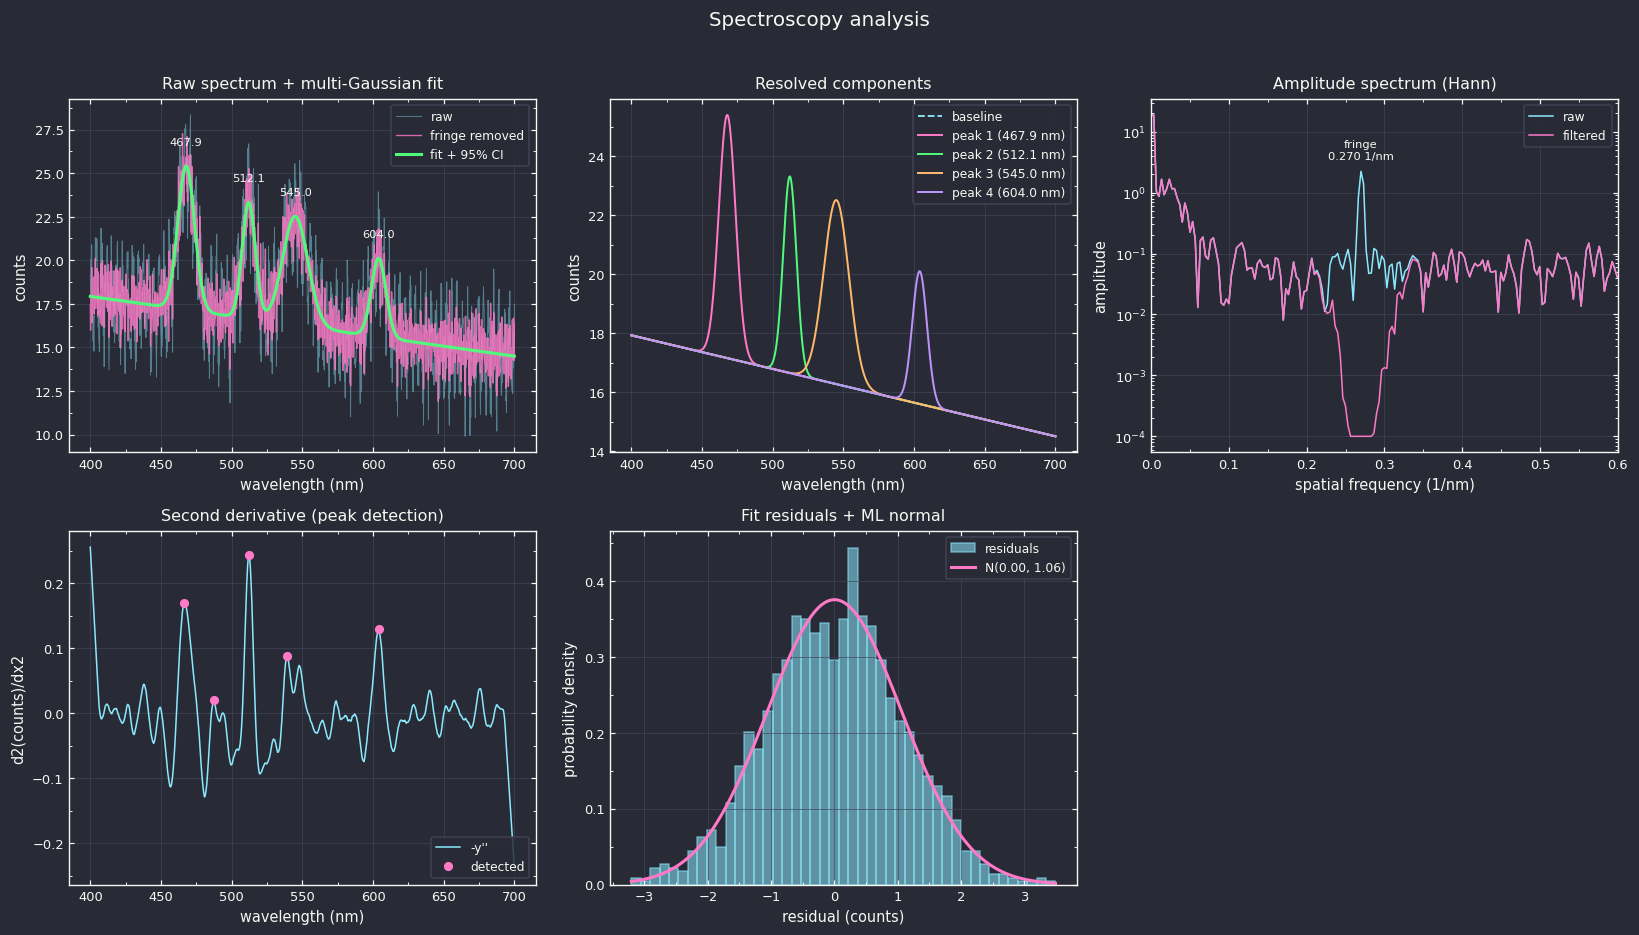


  STEP 10  project tree + .lml round-trip
Project              spectroscopy demo
  |- Spreadsheet          data
    |- Column               wavelength  [Double, 1500 rows, X]
    |- Column               counts  [Double, 1500 rows, Y]
  |- Spreadsheet          analysis results
    |- Column               wavelength  [Double, 1500 rows, X]
    |- Column               filtered  [Double, 1500 rows, Y]
    |- Column               smoothed  [Double, 1500 rows, Y]
    |- Column               baseline  [Double, 1500 rows, Y]
    |- Column               fit  [Double, 1500 rows, Y]
    |- Column               residuals  [Double, 1500 rows, Y]
    |- Column               cumulative  [Double, 1500 rows, Y]
  |- Spreadsheet          fit parameters
    |- Column               value  [Double, 14 rows, Y]
    |- Column               error  [Double, 14 rows, YError]
  |- Worksheet            Spectroscopy analysis
    |- CartesianPlot        raw & fit
      |- XYCurve              raw
      |- XYCurve 

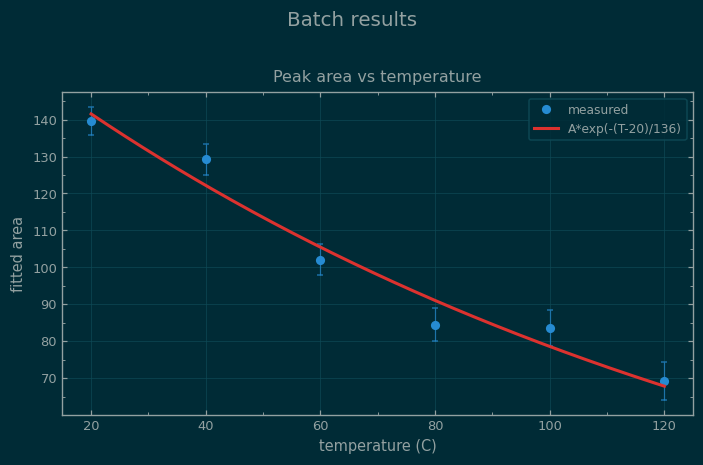

  measured centre drift 41.59 pm/C (injected 45.0)

  APPENDIX  the same workflow on the real pylabplot SDK
from pylabplot import *                        # every name below is identical
spreadsheet = Spreadsheet("data")
AsciiFilter().readDataFromFile("spectrum.dat", spreadsheet)
worksheet = Worksheet("worksheet"); plotArea = CartesianPlot("plot area")
plotArea.setType(CartesianPlot.Type.FourAxes); plotArea.addLegend()
worksheet.addChild(plotArea)
curve = XYCurve("spectrum")
curve.setXColumn(spreadsheet.column(0)); curve.setYColumn(spreadsheet.column(1))
plotArea.addChild(curve)
fitCurve = XYFitCurve("fit"); fitData = fitCurve.fitData()
fitData.modelCategory = nsl_fit_model_peak; fitData.modelType = nsl_fit_model_gaussian
fitData.degree = 4
XYFitCurve.initFitData(fitData); fitCurve.setFitData(fitData); fitCurve.recalculate()
worksheet.setTheme("Dracula")
worksheet.exportToFile("result.pdf", Worksheet.ExportFormat.PDF)
# pylabplot ships INSIDE a LabPlot install, not on PyPI, and upstrea

In [1]:
banner("STEP 11  batch: import -> filter -> fit -> secondary fit")
bd = os.path.join(OUT, "batch"); os.makedirs(bd, exist_ok=True)
temps = [20, 40, 60, 80, 100, 120]
for T in temps:
    yy = 18. - .012 * (wl - 400)
    for a, mu, s in TRUE:
        yy = yy + nsl_fit_model.gaussian(wl, a * math.exp(-(T-20)/140), mu + .045*(T-20),
                                         s * (1 + .004*(T-20)))
    with open(os.path.join(bd, f"run_{T:03d}C.dat"), "w") as fh:
        fh.write(f"# T = {T} C\nwavelength\tcounts\n")
        fh.writelines(f"{a:.4f}\t{b:.5f}\n"
                      for a, b in zip(wl, yy + np.random.normal(0, 1.1, wl.size)))

def analyse(path):
    sp = Spreadsheet(os.path.basename(path)); AsciiFilter().readDataFromFile(path, sp)
    q = XYFitCurve("fit", sp.column(0), sp.column(1), multi_gauss, p0, names, bounds=(lo, hi)) \
        .recalculate(showConfidenceInterval=False).fitResult
    return {"file": os.path.basename(path), "area": q.values[8], "area_err": q.errors[8],
            "centre": q.values[9], "centre_err": q.errors[9], "R2": q.gof["R^2"]}

t0 = time.perf_counter()
df = pd.DataFrame([analyse(os.path.join(bd, f)) for f in sorted(os.listdir(bd))])
df.insert(1, "T_C", temps)
print(df.to_string(index=False, float_format=lambda v: f"{v:9.4f}"),
      f"\n  {len(df)} files in {time.perf_counter()-t0:.2f} s")
arr = nsl_fit.fit(lambda T, A, T0: A * np.exp(-(T-20)/T0), df.T_C.values, df.area.values,
                  [140., 140.], yerr=df.area_err.values, paramNames=["A", "T0"])
arr.report("Secondary fit :: peak-3 area vs temperature")
print(f"  injected quench constant 140.0 -> recovered {arr.values[1]:.1f} +- {arr.errors[1]:.1f}")

ws2 = Worksheet("Batch results", figsize=(6.5, 4.2)); ws2.setTheme("SolarizedDark")
q1 = CartesianPlot("area", "Peak area vs temperature", "temperature (C)", "fitted area").addLegend()
c = XYCurve("measured", df.T_C.values, df.area.values, lineStyle=None, symbolStyle="o", symbolSize=6)
c.yErrorColumn = df.area_err.values; q1.addChild(c); Tg = np.linspace(20, 120, 200)
q1.addChild(XYCurve(f"A*exp(-(T-20)/{arr.values[1]:.0f})", Tg,
                    arr.values[0] * np.exp(-(Tg-20)/arr.values[1]), lineWidth=2.))
ws2.addChild(q1); ws2.render()
ws2.exportToFile(os.path.join(OUT, "batch_results.png")); ws2.show()
sl = np.polyfit(df.T_C, df.centre, 1)[0]
print(f"  measured centre drift {sl*1000:.2f} pm/C (injected 45.0)")

banner("APPENDIX  the same workflow on the real pylabplot SDK")
print(textwrap.dedent("""
    from pylabplot import *                        # every name below is identical
    spreadsheet = Spreadsheet("data")
    AsciiFilter().readDataFromFile("spectrum.dat", spreadsheet)
    worksheet = Worksheet("worksheet"); plotArea = CartesianPlot("plot area")
    plotArea.setType(CartesianPlot.Type.FourAxes); plotArea.addLegend()
    worksheet.addChild(plotArea)
    curve = XYCurve("spectrum")
    curve.setXColumn(spreadsheet.column(0)); curve.setYColumn(spreadsheet.column(1))
    plotArea.addChild(curve)
    fitCurve = XYFitCurve("fit"); fitData = fitCurve.fitData()
    fitData.modelCategory = nsl_fit_model_peak; fitData.modelType = nsl_fit_model_gaussian
    fitData.degree = 4
    XYFitCurve.initFitData(fitData); fitCurve.setFitData(fitData); fitCurve.recalculate()
    worksheet.setTheme("Dracula")
    worksheet.exportToFile("result.pdf", Worksheet.ExportFormat.PDF)
    # pylabplot ships INSIDE a LabPlot install, not on PyPI, and upstream still marks
    # the SDK experimental -- no API/ABI stability guarantee yet.
""").strip())

banner("done")
for f in sorted(os.listdir(OUT)):
    if os.path.isfile(q := os.path.join(OUT, f)):
        print(f"  {f:<26}{os.path.getsize(q)/1024:>9.1f} kB")
if IN_COLAB: print(f"\n  from google.colab import files; files.download('{OUT}/worksheet.pdf')")